In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
from datetime import datetime 
import time
from torch.utils.data import Dataset, DataLoader
from itertools import product
from torch.utils.data.dataset import TensorDataset

SEED = 123
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

In [ ]:
def seed_everything(SEED):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

# Model definition

In [ ]:


NUM_CLASSES = 10
IMAGE_HEIGHT, IMAGE_WIDTH = 48, 60


class LocalizationCNN(nn.Module):
    def __init__(self, channels=(16, 32, 64), hidden_dim=256, dropout=0.0, num_classes=NUM_CLASSES):
        super().__init__()
        blocks = []
        in_ch = 1
        for out_ch in channels:
            blocks.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ])
            in_ch = out_ch

        self.features = nn.Sequential(*blocks)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, IMAGE_HEIGHT, IMAGE_WIDTH)
            feat_dim = self.features(dummy).reshape(1, -1).shape[1]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes + 5),
        )

    def forward(self, x):
        return self.head(self.features(x))


model_configs = {
    'small': {'channels': (16, 32), 'hidden_dim': 128, 'dropout': 0.10},
    'base': {'channels': (16, 32, 64), 'hidden_dim': 256, 'dropout': 0.15},
    'deep': {'channels': (16, 32, 64, 96), 'hidden_dim': 256, 'dropout': 0.20},
}

Training on device cuda.


## Localization


In [3]:
def localization_loss(y_pred, y_true):
    obj_true = y_true[:, 0].float()

    detection_loss = F.binary_cross_entropy_with_logits(
        y_pred[:, 0], obj_true, reduction='none'
    )

    bbox_loss = F.mse_loss(
        torch.sigmoid(y_pred[:, 1:5]), y_true[:, 1:5].float(), reduction='none'
    ).mean(dim=1)

    class_targets = y_true[:, 5].long().clamp(min=0, max=y_pred.shape[1] - 6)
    class_loss = F.cross_entropy(y_pred[:, 5:], class_targets, reduction='none')

    total_loss = torch.where(
        obj_true > 0.5,
        detection_loss + bbox_loss + class_loss,
        detection_loss,
    )
    return total_loss.mean()



### Load data and preprocessing

In [4]:
data_path = '../data_2/'


def safe_load(path):
    if hasattr(torch.serialization, 'safe_globals'):
        with torch.serialization.safe_globals([TensorDataset]):
            return torch.load(path, map_location='cpu')
    torch.serialization.add_safe_globals([TensorDataset])
    return torch.load(path, map_location='cpu')


train_data = safe_load(f"{data_path}localization_train.pt")
val_data = safe_load(f"{data_path}localization_val.pt")
test_data = safe_load(f"{data_path}localization_test.pt")

print(len(train_data))
print(len(val_data))
print(len(test_data))

59400
6600
11000


### Exploratory Data Analysis
This section summarizes the dataset, checks class balance across splits, and visualizes a few annotated test samples before normalization and training.


Dataset summary
Image size: (48, 60) | Number of classes: 10
Target format: [objectness, x_center, y_center, width, height, class_id] | target shape: (6,)
Train: 59400 samples | 54000 labeled objects | 5400 background-only samples | avg box area: 0.0947
Validation: 6600 samples | 6000 labeled objects | 600 background-only samples | avg box area: 0.0936
Test: 11000 samples | 10000 labeled objects | 1000 background-only samples | avg box area: 0.0943
Overall class counts: Class 0=6903, Class 1=7877, Class 2=6990, Class 3=7141, Class 4=6824, Class 5=6313, Class 6=6876, Class 7=7293, Class 8=6825, Class 9=6958


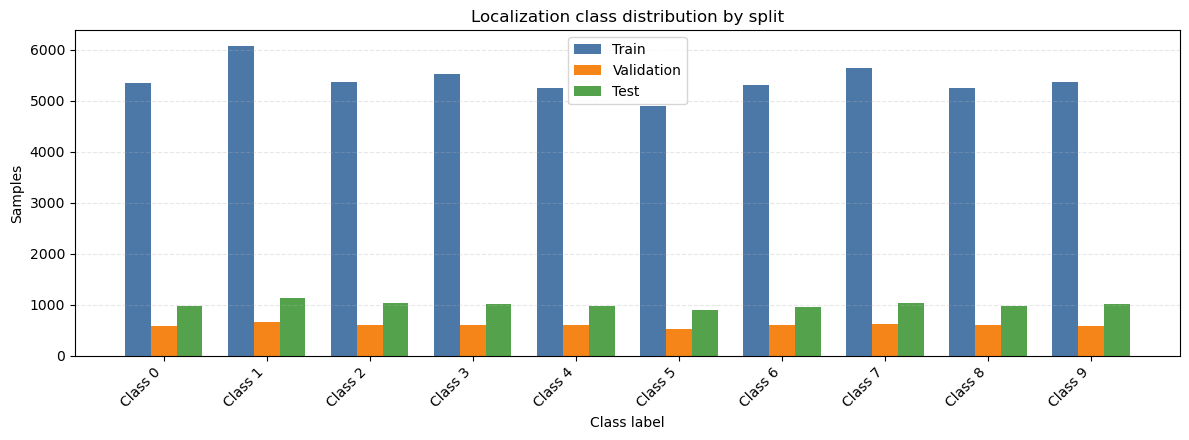

In [5]:
# Collect per-split class counts and a few summary statistics.
eda_class_names = [f"Class {class_idx}" for class_idx in range(NUM_CLASSES)]
localization_splits = {
    "Train": train_data,
    "Validation": val_data,
    "Test": test_data,
}

split_class_counts = {}
split_metadata = {}

for split_name, dataset in localization_splits.items():
    class_counts = torch.zeros(NUM_CLASSES, dtype=torch.long)
    object_count = 0
    bbox_areas = []

    for _, target in dataset:
        target = target.float()
        has_object = bool(target[0].item() > 0.5)
        if not has_object:
            continue

        object_count += 1
        label = int(target[5].item())
        class_counts[label] += 1
        bbox_areas.append(float((target[3] * target[4]).item()))

    split_class_counts[split_name] = class_counts
    split_metadata[split_name] = {
        "samples": len(dataset),
        "object_samples": object_count,
        "background_samples": len(dataset) - object_count,
        "avg_bbox_area": sum(bbox_areas) / len(bbox_areas) if bbox_areas else 0.0,
    }

overall_class_counts = torch.stack(list(split_class_counts.values())).sum(dim=0)
sample_image, sample_target = train_data[0]

print("Dataset summary")
print(f"Image size: {tuple(sample_image.shape[-2:])} | Number of classes: {NUM_CLASSES}")
print(
    f"Target format: [objectness, x_center, y_center, width, height, class_id] | "
    f"target shape: {tuple(sample_target.shape)}"
)
for split_name, metadata in split_metadata.items():
    print(
        f"{split_name}: {metadata['samples']} samples | "
        f"{metadata['object_samples']} labeled objects | "
        f"{metadata['background_samples']} background-only samples | "
        f"avg box area: {metadata['avg_bbox_area']:.4f}"
    )
print(
    "Overall class counts: "
    + ", ".join(
        f"{class_name}={int(count)}"
        for class_name, count in zip(eda_class_names, overall_class_counts.tolist())
    )
)

# Visualize the class distribution for each split.
class_positions = torch.arange(NUM_CLASSES, dtype=torch.float32)
bar_width = 0.25
split_colors = {
    "Train": "#4C78A8",
    "Validation": "#F58518",
    "Test": "#54A24B",
}

fig, ax = plt.subplots(figsize=(12, 4.5))
for offset, (split_name, counts) in enumerate(split_class_counts.items()):
    shift = (offset - (len(split_class_counts) - 1) / 2) * bar_width
    ax.bar(
        (class_positions + shift).tolist(),
        counts.tolist(),
        width=bar_width,
        label=split_name,
        color=split_colors[split_name],
    )

ax.set_title("Localization class distribution by split")
ax.set_xlabel("Class label")
ax.set_ylabel("Samples")
ax.set_xticks(class_positions.tolist())
ax.set_xticklabels(eda_class_names, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


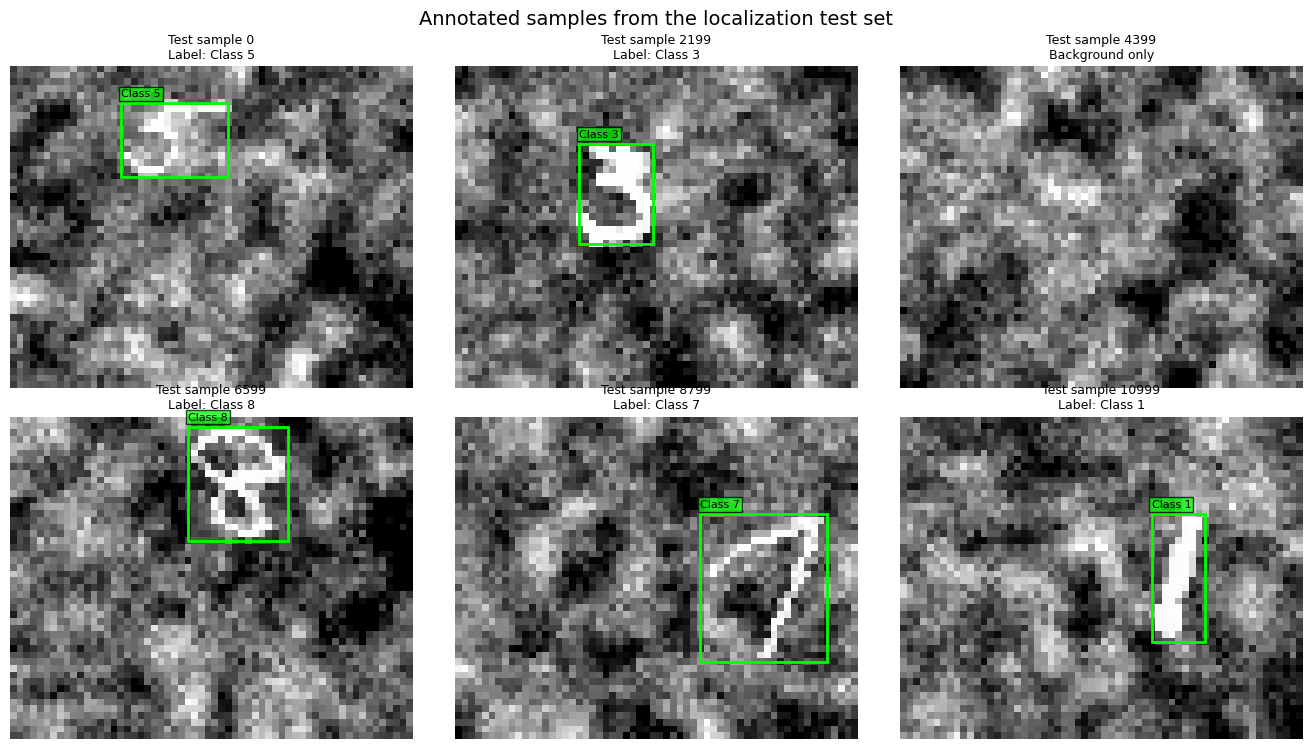

In [6]:
# Plot a small, evenly spaced subset of the test set with localization annotations.
def _eda_bbox_center_to_rect(target, image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    x_center, y_center, box_w, box_h = target[1:5].tolist()
    left = (x_center - 0.5 * box_w) * image_width
    top = (y_center - 0.5 * box_h) * image_height
    return left, top, box_w * image_width, box_h * image_height


num_samples = min(6, len(test_data))
sample_indices = torch.linspace(0, len(test_data) - 1, steps=num_samples).long().tolist()
num_cols = min(3, num_samples)
num_rows = (num_samples + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4.5 * num_cols, 3.8 * num_rows))
if hasattr(axes, "ravel"):
    axes = axes.ravel()
else:
    axes = [axes]

for ax, sample_idx in zip(axes, sample_indices):
    image, target = test_data[int(sample_idx)]
    image = image.float()
    if image.ndim == 3:
        image = image.squeeze(0)
    target = target.float()

    ax.imshow(image, cmap="gray")

    if target[0].item() > 0.5:
        left, top, width, height = _eda_bbox_center_to_rect(target)
        label_name = eda_class_names[int(target[5].item())]
        ax.add_patch(
            plt.Rectangle((left, top), width, height, fill=False, edgecolor="lime", linewidth=2)
        )
        ax.text(
            left,
            max(top - 1, 0),
            label_name,
            fontsize=8,
            color="black",
            bbox=dict(facecolor="lime", alpha=0.75, pad=1.5),
        )
        ax.set_title(f"Test sample {sample_idx}\nLabel: {label_name}", fontsize=9)
    else:
        ax.set_title(f"Test sample {sample_idx}\nBackground only", fontsize=9)

    ax.axis("off")

for ax in axes[len(sample_indices):]:
    ax.axis("off")

plt.suptitle("Annotated samples from the localization test set", fontsize=14)
plt.tight_layout()
plt.show()


### Normalize Images

In [ ]:
def _ensure_channel_first(image):
    image = image.float()
    if image.ndim == 2:
        image = image.unsqueeze(0)
    return image


class LocalizationDataset(Dataset):
    def __init__(self, data, preprocessor=None):
        self.data = data
        self.preprocessor = preprocessor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, target = self.data[idx]
        image = _ensure_channel_first(image)
        target = target.float()
        if self.preprocessor is not None:
            image = self.preprocessor(image)
        return image, target


train_images = torch.stack([_ensure_channel_first(x) for x, _ in train_data], dim=0)
train_mean = train_images.mean()
train_std = train_images.std().clamp_min(1e-6)
print(f"Train mean: {train_mean.item():.4f}, train std: {train_std.item():.4f}")


def preprocessor(x):
    return (x - train_mean) / train_std

g = torch.Generator().manual_seed(SEED)
batch_size = 128
train_loader = DataLoader(LocalizationDataset(train_data, preprocessor), batch_size=batch_size, shuffle=True, generator=g)
val_loader = DataLoader(LocalizationDataset(val_data, preprocessor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(LocalizationDataset(test_data, preprocessor), batch_size=batch_size, shuffle=False)



Train mean: 0.4171, train std: 0.2138


### Hyperparameter tuning and training

In [8]:
def train_single_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, weight_decay=0.0, optimizer = "adam"):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_iou': [],
        'val_overall': [],
    }

    best_val_overall = float('-inf')
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss = localization_loss(preds, targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total_iou = 0.0
        total_objects = 0

        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = targets.to(device)
                preds = model(images)
                loss = localization_loss(preds, targets)
                running_val_loss += loss.item() * images.size(0)

                true_obj = targets[:, 0] > 0.5
                if not true_obj.any():
                    continue

                pred_obj = torch.sigmoid(preds[:, 0]) > 0.5
                pred_cls = preds[:, 5:].argmax(dim=1)
                true_cls = targets[:, 5].long()

                correct += (pred_obj & (pred_cls == true_cls) & true_obj).sum().item()

                pred_bbox = torch.sigmoid(preds[:, 1:5])[true_obj]
                true_bbox = targets[:, 1:5][true_obj]
                detected = pred_obj[true_obj]

                pred_min = pred_bbox[:, :2] - 0.5 * pred_bbox[:, 2:]
                pred_max = pred_bbox[:, :2] + 0.5 * pred_bbox[:, 2:]
                true_min = true_bbox[:, :2] - 0.5 * true_bbox[:, 2:]
                true_max = true_bbox[:, :2] + 0.5 * true_bbox[:, 2:]

                inter_min = torch.maximum(pred_min, true_min)
                inter_max = torch.minimum(pred_max, true_max)
                inter_wh = (inter_max - inter_min).clamp(min=0)
                inter_area = inter_wh[:, 0] * inter_wh[:, 1]

                pred_area = (pred_bbox[:, 2] * pred_bbox[:, 3]).clamp(min=0)
                true_area = (true_bbox[:, 2] * true_bbox[:, 3]).clamp(min=0)
                union_area = pred_area + true_area - inter_area
                iou = torch.where(union_area > 0, inter_area / union_area, torch.zeros_like(union_area))
                iou = iou * detected.float()

                total_iou += iou.sum().item()
                total_objects += true_obj.sum().item()

        val_loss = running_val_loss / len(val_loader.dataset)
        val_acc = correct / total_objects if total_objects > 0 else 0.0
        val_iou = total_iou / total_objects if total_objects > 0 else 0.0
        val_overall = 0.5 * (val_acc + val_iou)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_iou'].append(val_iou)
        history['val_overall'].append(val_overall)

        if val_overall > best_val_overall:
            best_val_overall = val_overall
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
            f"val acc: {val_acc:.4f} | val IoU: {val_iou:.4f} | val overall: {val_overall:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_overall


hyperparam_grid = {
    "model_name": ["small", "base", "deep"],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0.0, 1e-4, 1e-3],
    "num_epochs": [20],
}

hyperparam_candidates = [
    {
        'model_name': model_name,
        'lr': lr,
        'weight_decay': weight_decay,
        'num_epochs': num_epochs,
    }
    for model_name, lr, weight_decay, num_epochs in product(
        hyperparam_grid['model_name'],
        hyperparam_grid['lr'],
        hyperparam_grid['weight_decay'],
        hyperparam_grid['num_epochs'],
    )
]

In [ ]:
trained_models = {}
training_histories = {}
tuning_results = []
total_start = time.perf_counter()

for trial_idx, candidate in enumerate(hyperparam_candidates, start=1):
   
    trial_start = time.perf_counter()
    model_name = candidate['model_name']
    lr = candidate['lr']
    weight_decay = candidate['weight_decay']
    num_epochs = candidate['num_epochs']
    cfg = model_configs[model_name]
    trial_name = (
        f"trial_{trial_idx:02d}_{model_name}_"
        f"lr{lr:.0e}_wd{weight_decay:.0e}_e{num_epochs}"
    )

    print(
        f"\n[{trial_idx}/{len(hyperparam_candidates)}] {trial_name} | "
        f"channels={cfg['channels']} hidden={cfg['hidden_dim']} dropout={cfg['dropout']}"
    )
    seed_everything(SEED)
    current_model = LocalizationCNN(**cfg).to(device)
    current_model, history, best_val_overall = train_single_model(
        current_model,
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        lr=lr,
        weight_decay=weight_decay,
    )
    trial_seconds = time.perf_counter() - trial_start

    trained_models[trial_name] = current_model
    training_histories[trial_name] = history
    tuning_results.append({
        'trial_name': trial_name,
        'model_name': model_name,
        'lr': lr,
        'weight_decay': weight_decay,
        'num_epochs': num_epochs,
        'best_val_overall': best_val_overall,
        'train_seconds': trial_seconds,
    })
    print(
        f"Best val overall for {trial_name}: {best_val_overall:.4f} | "
        f"trial time: {trial_seconds:.1f}s ({trial_seconds / 60:.2f} min)"
    )

total_seconds = time.perf_counter() - total_start
tuning_results = sorted(tuning_results, key=lambda d: d['best_val_overall'], reverse=True)

print(
    f"\nTotal tuning/training time: {total_seconds:.1f}s "
    f"({total_seconds / 60:.2f} min)"
)
print('\nHyperparameter tuning summary (sorted by best val overall):')
for result in tuning_results:
    print(
        f"{result['trial_name']:>36s} | "
        f"best val overall: {result['best_val_overall']:.4f} | "
        f"time: {result['train_seconds']:.1f}s"
    )

best_trial_name = tuning_results[0]['trial_name']
model = trained_models[best_trial_name]
print(f"\nSelected best tuning trial: {best_trial_name}")



[1/27] trial_01_small_lr1e-03_wd0e+00_e20 | channels=(16, 32) hidden=128 dropout=0.1


Epoch 01/20 | train loss: 1.9767 | val loss: 1.7155 | val acc: 0.3292 | val IoU: 0.4533 | val overall: 0.3912


Epoch 02/20 | train loss: 1.5037 | val loss: 1.3440 | val acc: 0.4937 | val IoU: 0.4611 | val overall: 0.4774


Epoch 03/20 | train loss: 1.2095 | val loss: 1.1088 | val acc: 0.6013 | val IoU: 0.4649 | val overall: 0.5331


Epoch 04/20 | train loss: 0.9875 | val loss: 0.9769 | val acc: 0.6490 | val IoU: 0.4725 | val overall: 0.5608


...

Epoch 16/20 | train loss: 0.5760 | val loss: 0.5607 | val acc: 0.8048 | val IoU: 0.6140 | val overall: 0.7094


Epoch 17/20 | train loss: 0.5457 | val loss: 0.5255 | val acc: 0.8125 | val IoU: 0.6159 | val overall: 0.7142


Epoch 18/20 | train loss: 0.5203 | val loss: 0.5017 | val acc: 0.8248 | val IoU: 0.6131 | val overall: 0.7190


Epoch 19/20 | train loss: 0.4914 | val loss: 0.4819 | val acc: 0.8313 | val IoU: 0.6220 | val overall: 0.7267


Epoch 20/20 | train loss: 0.4723 | val loss: 0.4652 | val acc: 0.8393 | val IoU: 0.6244 | val overall: 0.7319
Best val overall for trial_27_deep_lr1e-04_wd1e-03_e20: 0.7319 | trial time: 78.0s (1.30 min)

Total tuning/training time: 2285.0s (38.08 min)

Hyperparameter tuning summary (sorted by best val overall):
   trial_23_deep_lr5e-04_wd1e-04_e20 | best val overall: 0.7902 | time: 75.5s
   trial_20_deep_lr1e-03_wd1e-04_e20 | best val overall: 0.7856 | time: 86.4s
   trial_24_deep_lr5e-04_wd1e-03_e20 | best val overall: 0.7794 | time: 74.4s
   trial_21_deep_lr1e-03_wd1e-03_e20 | best val overall: 0.7698 | time: 86.5s
   trial_14_base_lr5e-04_wd1e-04_e20 | best val overall: 0.7694 | time: 75.6s
   trial_22_deep_lr5e-04_wd0e+00_e20 | best val overall: 0.7647 | time: 87.3s
   trial_11_base_lr1e-03_wd1e-04_e20 | best val overall: 0.7644 | time: 100.1s
   trial_15_base_lr5e-04_wd1e-03_e20 | best val overall: 0.7636 | time: 91.8s
   trial_12_base_lr1e-03_wd1e-03_e20 | best val overall: 0.76

### Predictions

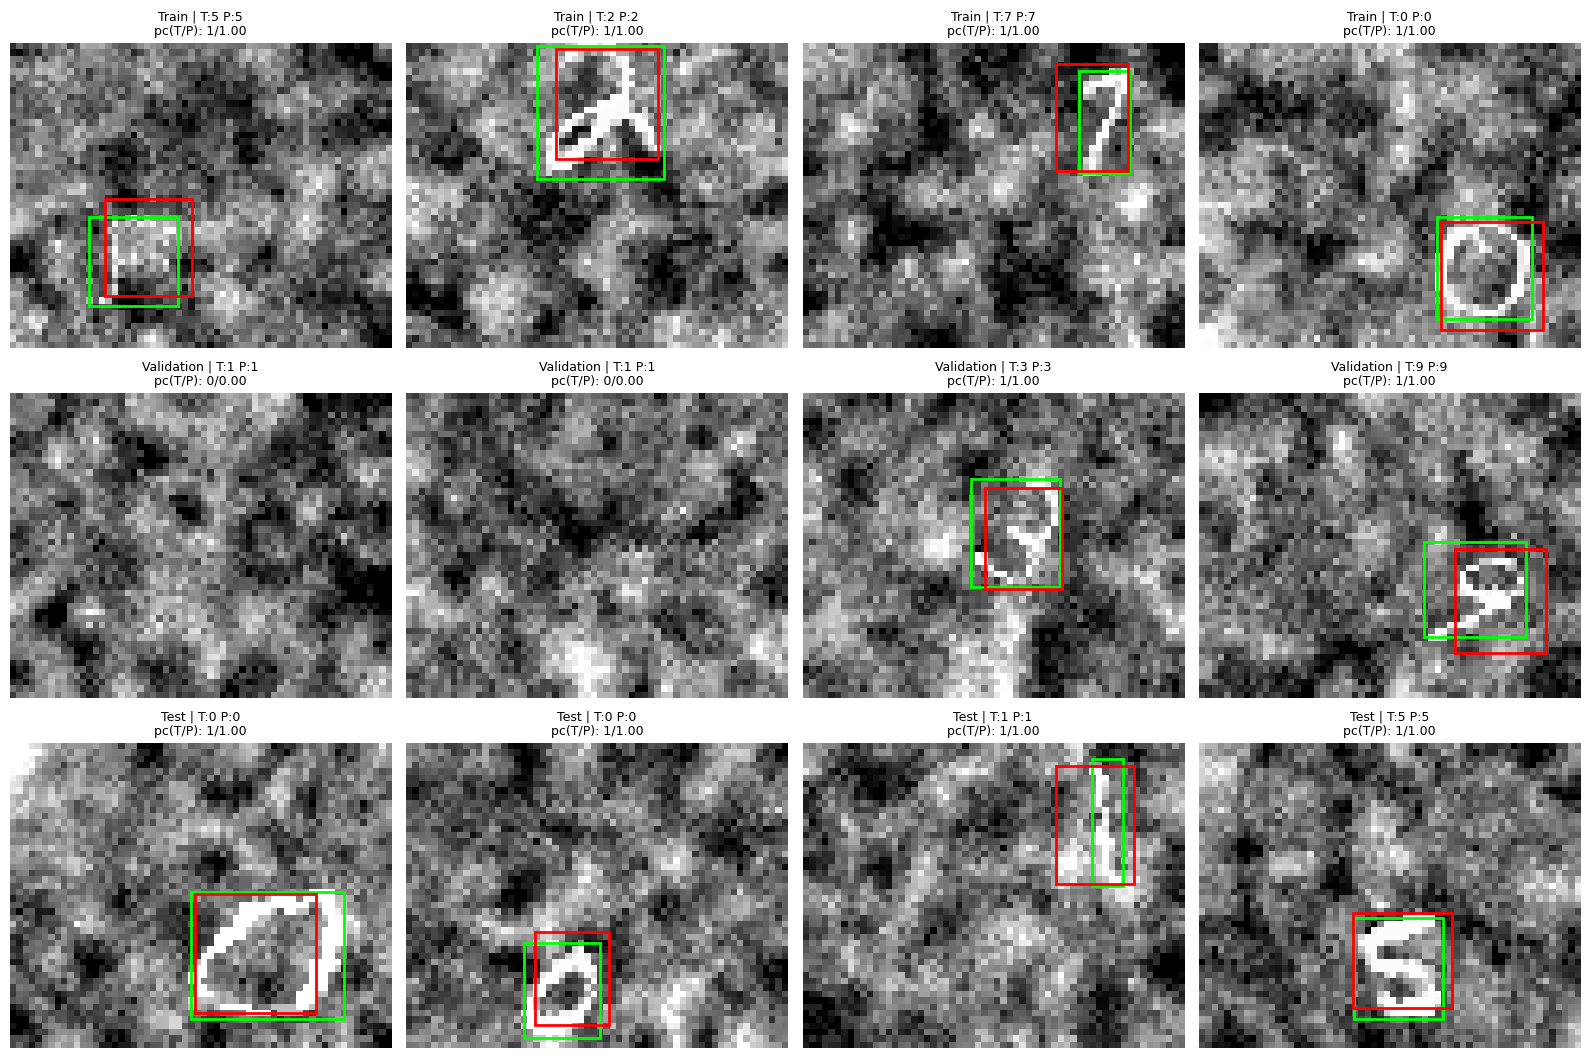

In [10]:
def _bbox_center_to_rect(bb, image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    x, y, w, h = bb.tolist()
    left = (x - 0.5 * w) * image_width
    top = (y - 0.5 * h) * image_height
    width = w * image_width
    height = h * image_height
    return left, top, width, height


plot_model = globals().get('best_model')
if plot_model is None:
    plot_model = globals().get('model')
if plot_model is None:
    raise RuntimeError('No trained model found. Run the training/model-selection cells first.')

plot_model.eval()

splits = [
    ('Train', train_data),
    ('Validation', val_data),
    ('Test', test_data),
]

samples_per_split = 4
fig, axes = plt.subplots(len(splits), samples_per_split, figsize=(4 * samples_per_split, 3.6 * len(splits)))

if len(splits) == 1:
    axes = [axes]

with torch.no_grad():
    for row, (split_name, dataset) in enumerate(splits):
        indices = torch.randperm(len(dataset))[:samples_per_split]
        for col, idx in enumerate(indices):
            ax = axes[row][col]
            image, target = dataset[int(idx)]
            image = _ensure_channel_first(image)

            model_input = preprocessor(image).unsqueeze(0).to(device)
            pred = plot_model(model_input).cpu().squeeze(0)

            pred_pc = torch.sigmoid(pred[0]).item()
            pred_label = pred[5:].argmax().item()
            pred_bbox = torch.sigmoid(pred[1:5])

            true_pc = int(target[0].item())
            true_label = int(target[5].item())
            true_bbox = target[1:5]

            ax.imshow(image.squeeze(0), cmap='gray')

            if true_pc == 1:
                l, t, w, h = _bbox_center_to_rect(true_bbox)
                ax.add_patch(plt.Rectangle((l, t), w, h, fill=False, edgecolor='lime', linewidth=2))

            if pred_pc > 0.5:
                l, t, w, h = _bbox_center_to_rect(pred_bbox)
                ax.add_patch(plt.Rectangle((l, t), w, h, fill=False, edgecolor='red', linewidth=2))

            ax.set_title(
                f"{split_name} | T:{true_label} P:{pred_label}\npc(T/P): {true_pc}/{pred_pc:.2f}",
                fontsize=9,
            )
            ax.axis('off')

plt.tight_layout()
plt.show()



### Model selection and evaluation

In [11]:
def intersection(bb1, bb2):
    """
    Compute intersection between 2 bb, in global frame of ref
    bb format: [x_center, y_center, width, height]
    """
    bb1 = torch.as_tensor(bb1, dtype=torch.float32)
    bb2 = torch.as_tensor(bb2, dtype=torch.float32)

    bb1_min = bb1[:2] - 0.5 * bb1[2:]
    bb1_max = bb1[:2] + 0.5 * bb1[2:]
    bb2_min = bb2[:2] - 0.5 * bb2[2:]
    bb2_max = bb2[:2] + 0.5 * bb2[2:]

    inter_min = torch.maximum(bb1_min, bb2_min)
    inter_max = torch.minimum(bb1_max, bb2_max)
    inter_wh = (inter_max - inter_min).clamp(min=0)
    return (inter_wh[0] * inter_wh[1]).item()


def IoU(bb1, bb2):
    """
    Compute IoU given 2 bb (local or global)
    """
    bb1 = torch.as_tensor(bb1, dtype=torch.float32)
    bb2 = torch.as_tensor(bb2, dtype=torch.float32)

    inter = intersection(bb1, bb2)
    area1 = (bb1[2] * bb1[3]).item()
    area2 = (bb2[2] * bb2[3]).item()
    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union


def compute_IoU_localization(model, loader, preprocessor):
    """
    Compute IoU performance of the model on the given dataset
    """
    model.eval()
    total_iou = 0.0
    total_objects = 0

    with torch.no_grad():
        for images, targets in loader:
            if preprocessor is not None:
                images = preprocessor(images)

            images = images.to(device)
            targets = targets.to(device)
            preds = model(images)

            true_obj = targets[:, 0] > 0.5
            if not true_obj.any():
                continue

            pred_obj = torch.sigmoid(preds[:, 0]) > 0.5
            pred_bbox = torch.sigmoid(preds[:, 1:5])
            true_bbox = targets[:, 1:5]

            pred_bbox = pred_bbox[true_obj]
            true_bbox = true_bbox[true_obj]
            detected = pred_obj[true_obj]

            pred_min = pred_bbox[:, :2] - 0.5 * pred_bbox[:, 2:]
            pred_max = pred_bbox[:, :2] + 0.5 * pred_bbox[:, 2:]
            true_min = true_bbox[:, :2] - 0.5 * true_bbox[:, 2:]
            true_max = true_bbox[:, :2] + 0.5 * true_bbox[:, 2:]

            inter_min = torch.maximum(pred_min, true_min)
            inter_max = torch.minimum(pred_max, true_max)
            inter_wh = (inter_max - inter_min).clamp(min=0)
            inter_area = inter_wh[:, 0] * inter_wh[:, 1]

            pred_area = (pred_bbox[:, 2] * pred_bbox[:, 3]).clamp(min=0)
            true_area = (true_bbox[:, 2] * true_bbox[:, 3]).clamp(min=0)
            union_area = pred_area + true_area - inter_area

            iou = torch.where(union_area > 0, inter_area / union_area, torch.zeros_like(union_area))
            iou = iou * detected.float()

            total_iou += iou.sum().item()
            total_objects += true_obj.sum().item()

    if total_objects == 0:
        return 0.0
    return total_iou / total_objects


def compute_accuracy_localization(model, loader, preprocessor):
    """
    Compute accuracy of the model on the given dataset
    """
    model.eval()
    total_objects = 0
    correct = 0

    with torch.no_grad():
        for images, targets in loader:
            if preprocessor is not None:
                images = preprocessor(images)

            images = images.to(device)
            targets = targets.to(device)
            preds = model(images)

            true_obj = targets[:, 0] > 0.5
            if not true_obj.any():
                continue

            pred_obj = torch.sigmoid(preds[:, 0]) > 0.5
            pred_cls = preds[:, 5:].argmax(dim=1)
            true_cls = targets[:, 5].long()

            batch_correct = pred_obj & (pred_cls == true_cls) & true_obj
            correct += batch_correct.sum().item()
            total_objects += true_obj.sum().item()

    if total_objects == 0:
        return 0.0
    return correct / total_objects


# Model selection based on validation overall performance
if 'trained_models' not in globals() or len(trained_models) == 0:
    trained_models = {'single_model': model}

validation_results = {}
for model_name, current_model in trained_models.items():
    val_acc = compute_accuracy_localization(current_model, val_loader, preprocessor=None)
    val_iou = compute_IoU_localization(current_model, val_loader, preprocessor=None)
    val_overall = 0.5 * (val_acc + val_iou)
    validation_results[model_name] = {
        'accuracy': val_acc,
        'iou': val_iou,
        'overall': val_overall,
    }

print('Validation results per model:')
for model_name, metrics in validation_results.items():
    print(
        f"{model_name:>8s} | "
        f"accuracy: {metrics['accuracy']:.4f} | "
        f"IoU: {metrics['iou']:.4f} | "
        f"overall: {metrics['overall']:.4f}"
    )

best_model_name = max(validation_results, key=lambda n: validation_results[n]['overall'])
best_model = trained_models[best_model_name]
model = best_model  # keep a common reference for downstream cells

print(f"\nSelected best model: {best_model_name}")

# Evaluate the best model on test data
test_acc = compute_accuracy_localization(best_model, test_loader, preprocessor=None)
test_iou = compute_IoU_localization(best_model, test_loader, preprocessor=None)
test_overall = 0.5 * (test_acc + test_iou)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test IoU:      {test_iou:.4f}")
print(f"Test overall:  {test_overall:.4f}")



Validation results per model:
trial_01_small_lr1e-03_wd0e+00_e20 | accuracy: 0.7355 | IoU: 0.4677 | overall: 0.6016
trial_02_small_lr1e-03_wd1e-04_e20 | accuracy: 0.7637 | IoU: 0.5530 | overall: 0.6583
trial_03_small_lr1e-03_wd1e-03_e20 | accuracy: 0.7958 | IoU: 0.5722 | overall: 0.6840
trial_04_small_lr5e-04_wd0e+00_e20 | accuracy: 0.7148 | IoU: 0.4556 | overall: 0.5852
trial_05_small_lr5e-04_wd1e-04_e20 | accuracy: 0.7395 | IoU: 0.5701 | overall: 0.6548
trial_06_small_lr5e-04_wd1e-03_e20 | accuracy: 0.7522 | IoU: 0.5934 | overall: 0.6728
trial_07_small_lr1e-04_wd0e+00_e20 | accuracy: 0.4663 | IoU: 0.4879 | overall: 0.4771
trial_08_small_lr1e-04_wd1e-04_e20 | accuracy: 0.4878 | IoU: 0.5113 | overall: 0.4996
trial_09_small_lr1e-04_wd1e-03_e20 | accuracy: 0.4440 | IoU: 0.5115 | overall: 0.4777
trial_10_base_lr1e-03_wd0e+00_e20 | accuracy: 0.9033 | IoU: 0.5611 | overall: 0.7322
trial_11_base_lr1e-03_wd1e-04_e20 | accuracy: 0.9078 | IoU: 0.6210 | overall: 0.7644
trial_12_base_lr1e-03_wd1e

Test accuracy: 0.9340
Test IoU:      0.6504
Test overall:  0.7922


### Per-model loss graphs

Creating 27 per-model loss graphs.


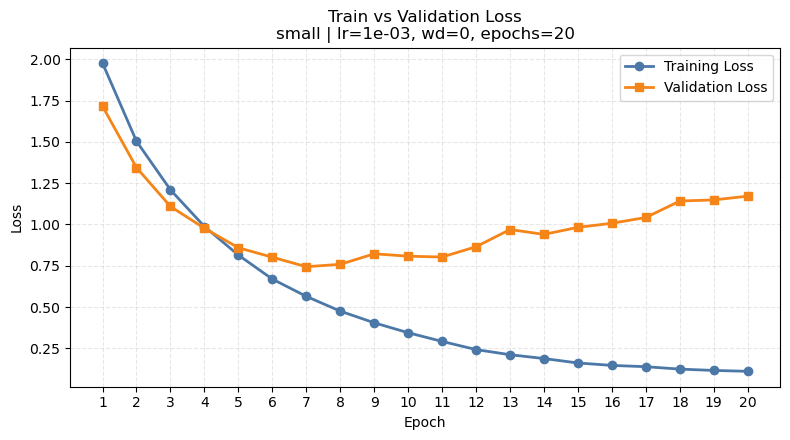

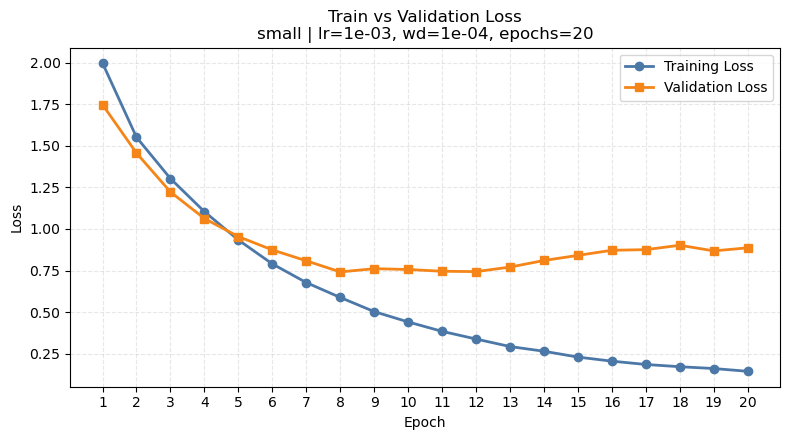

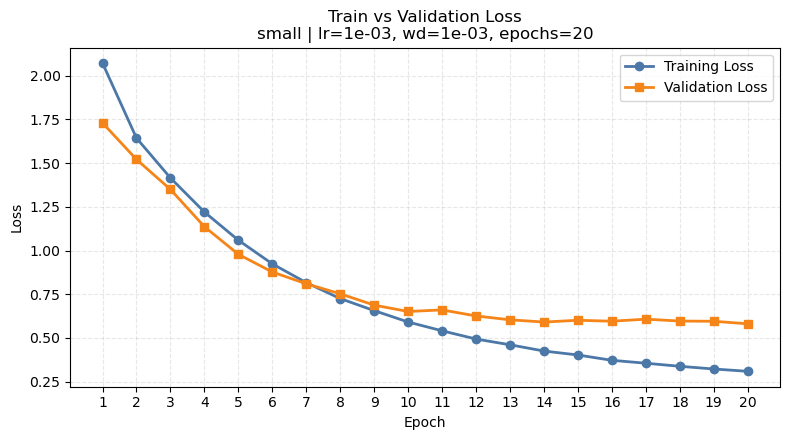

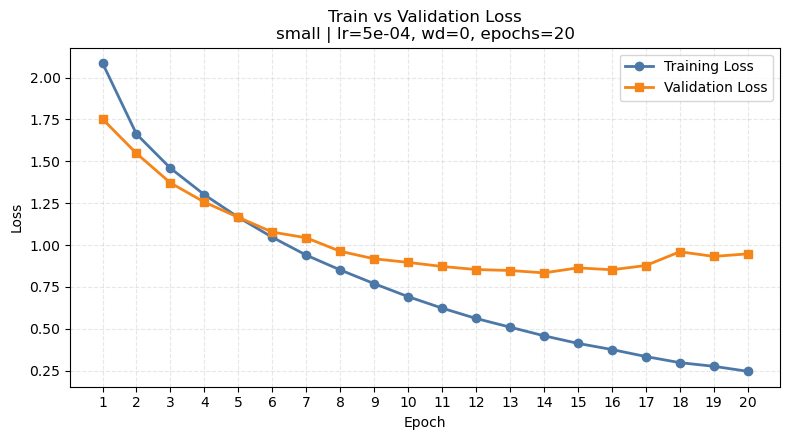

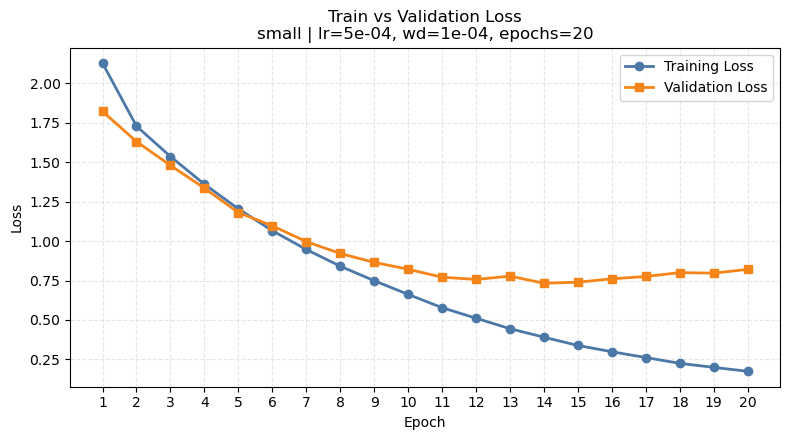

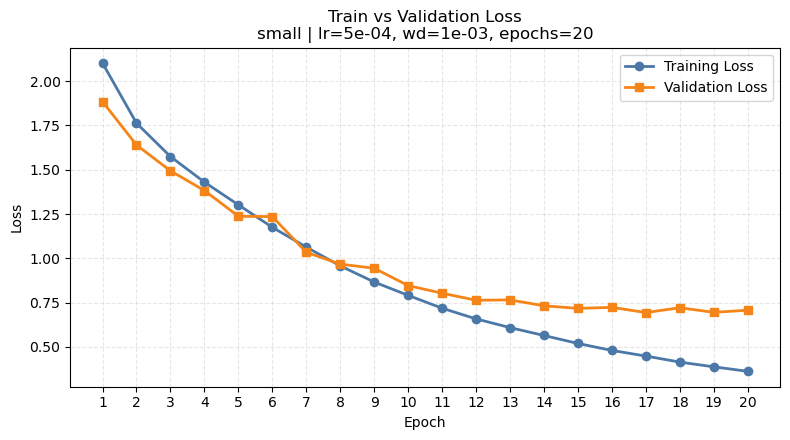

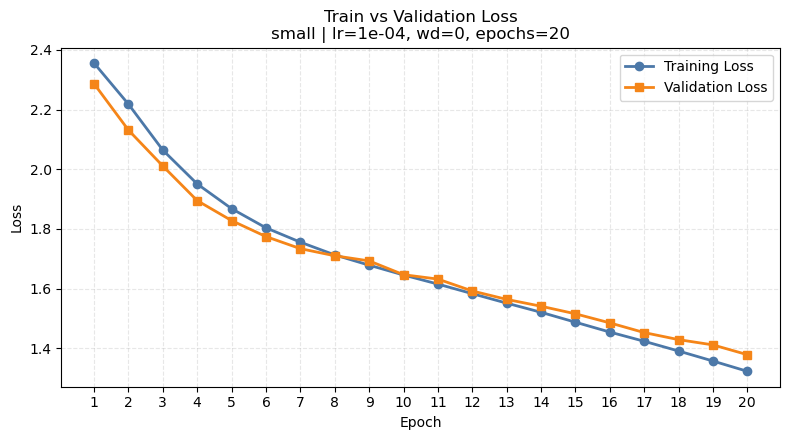

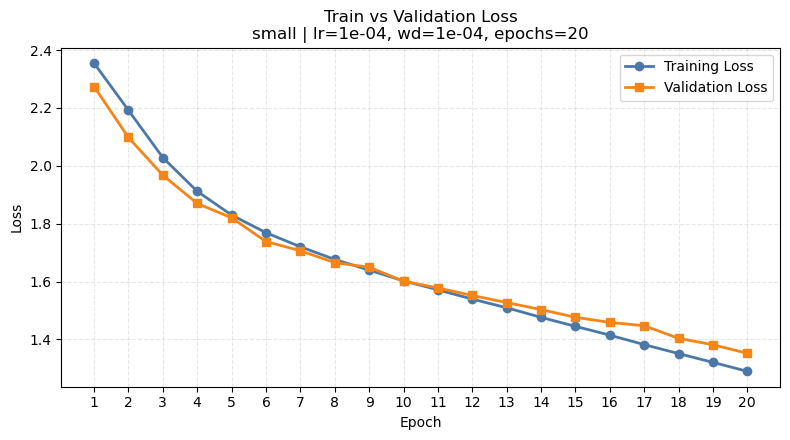

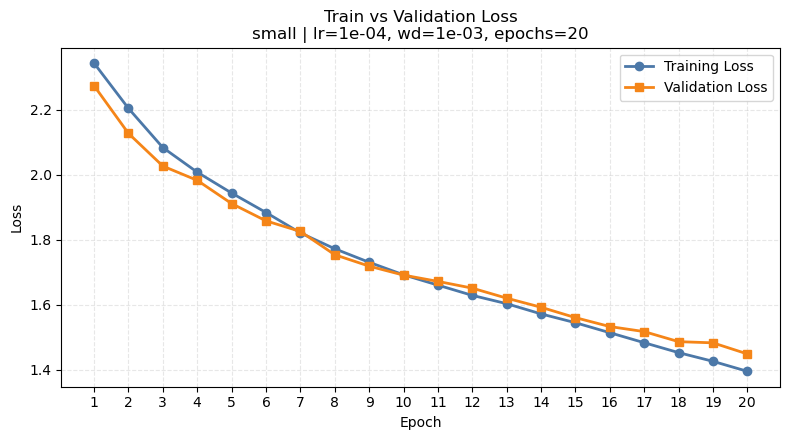

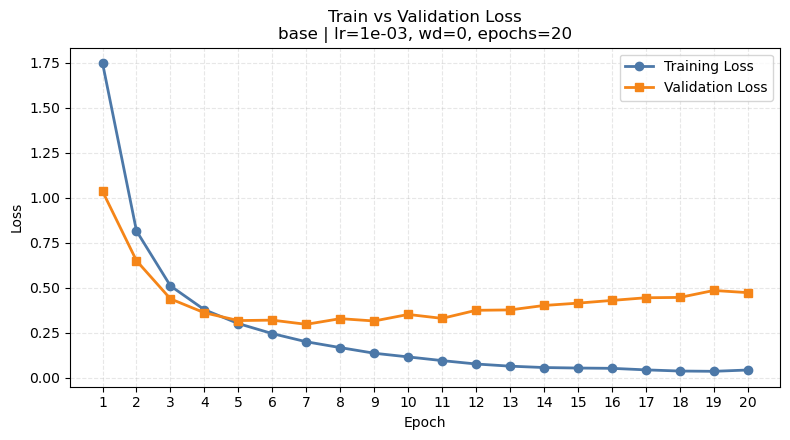

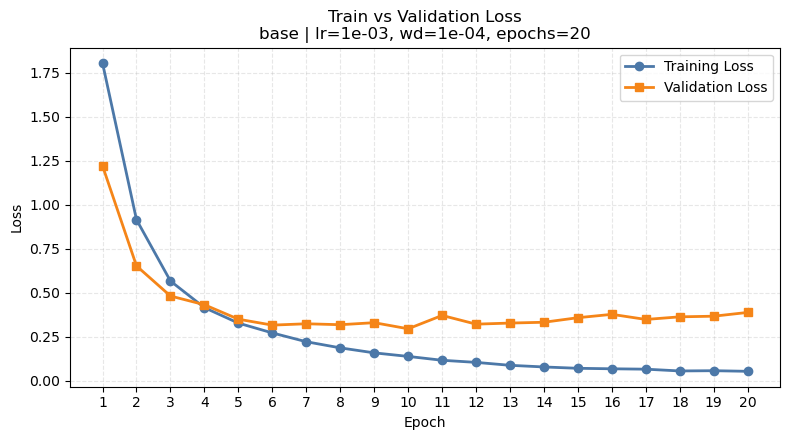

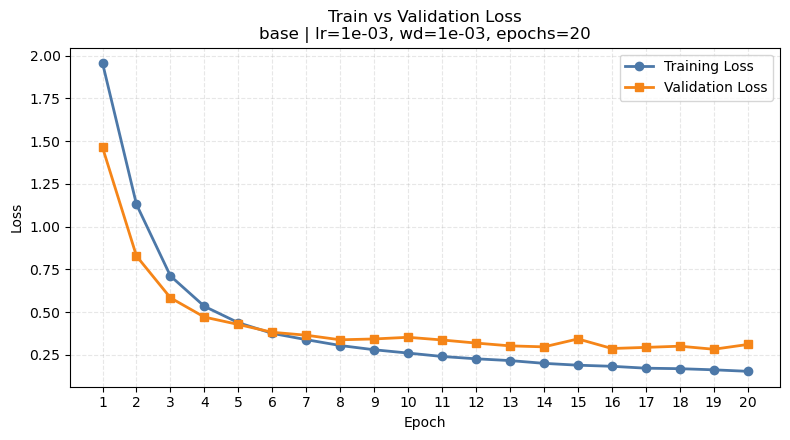

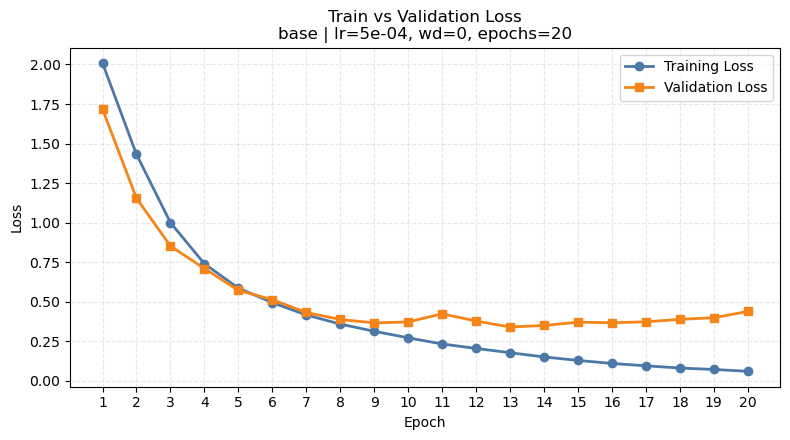

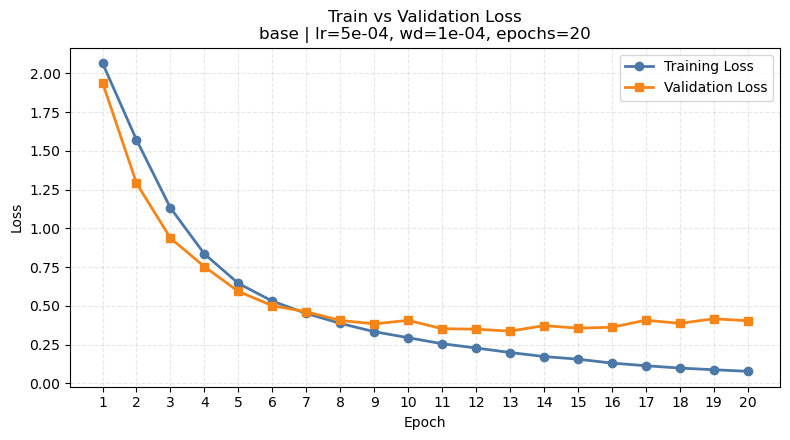

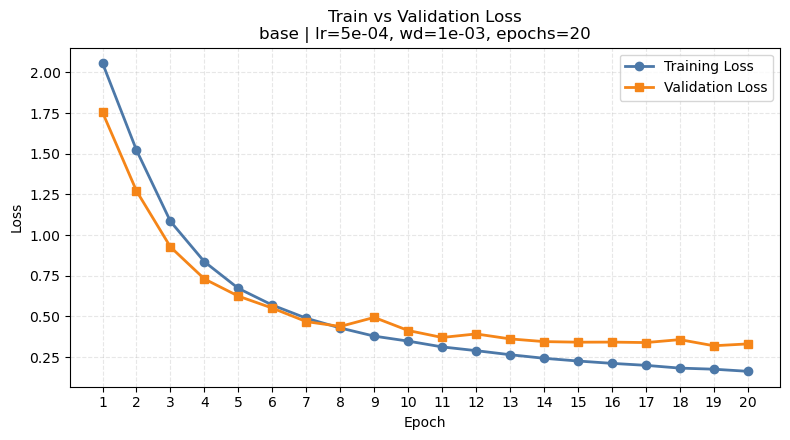

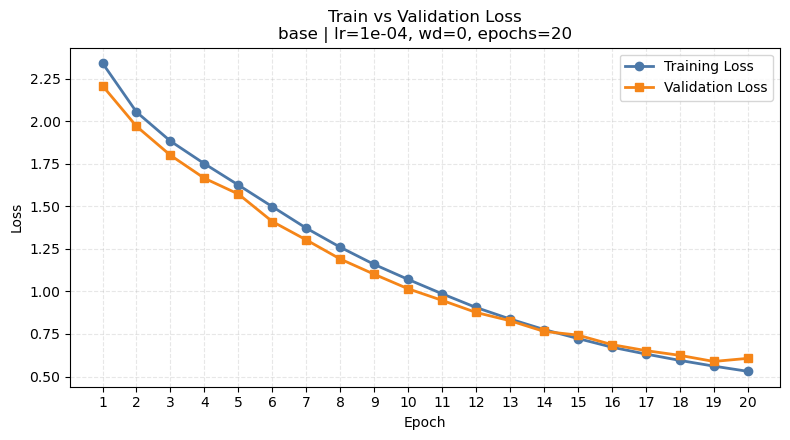

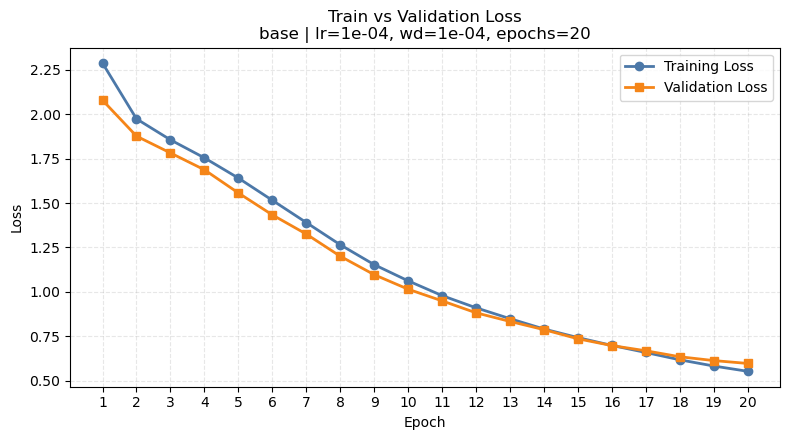

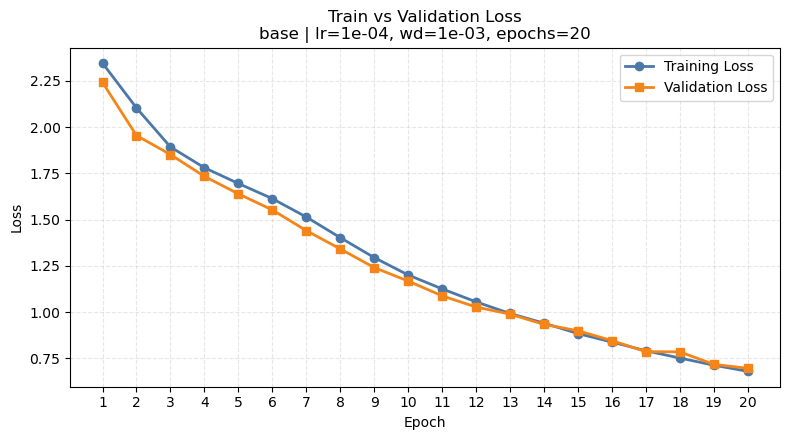

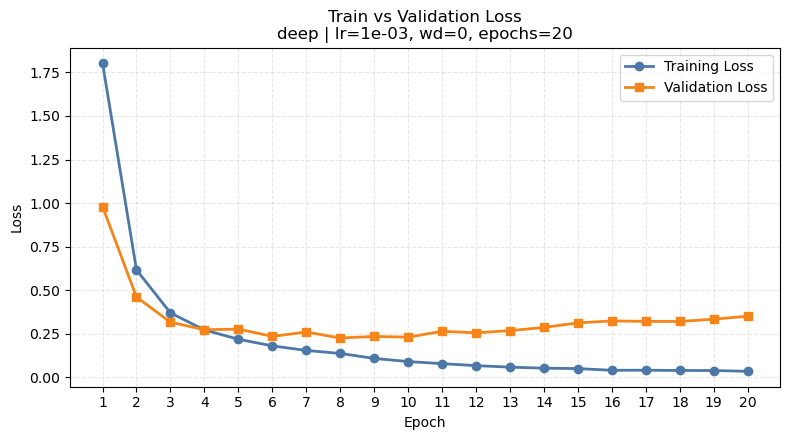

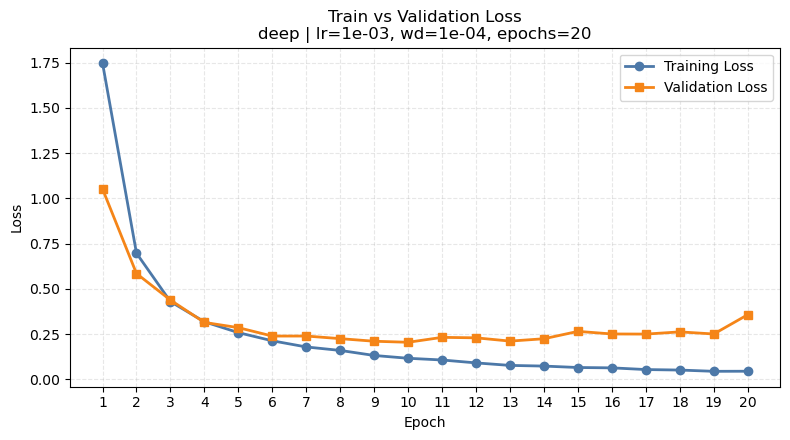

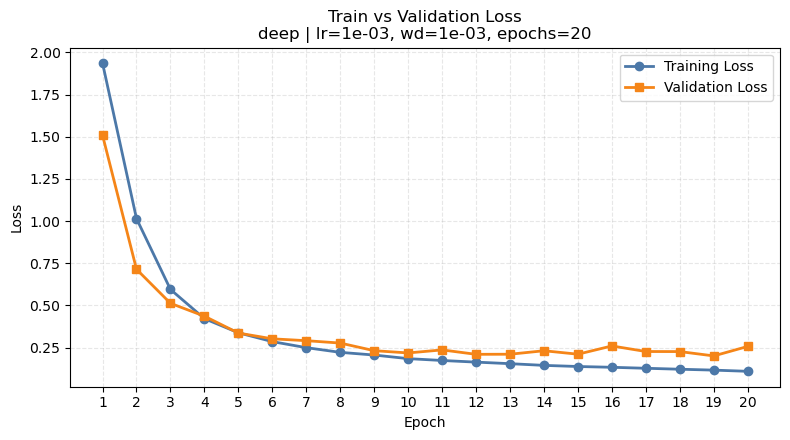

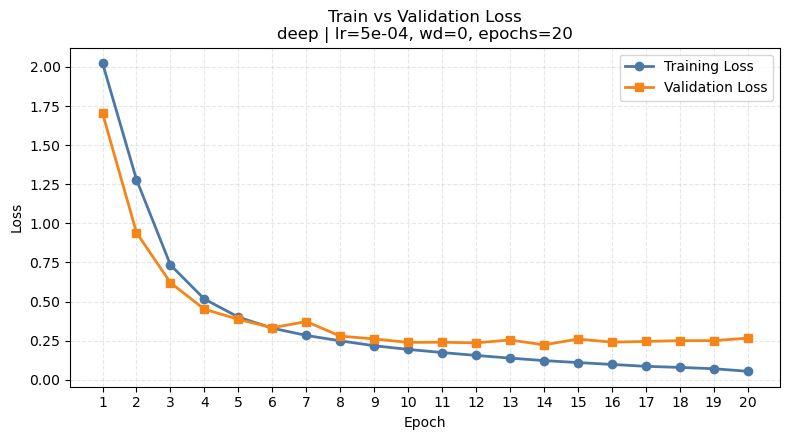

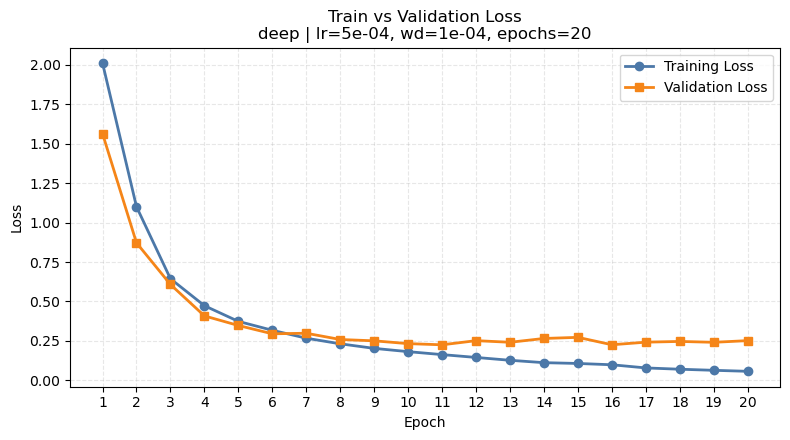

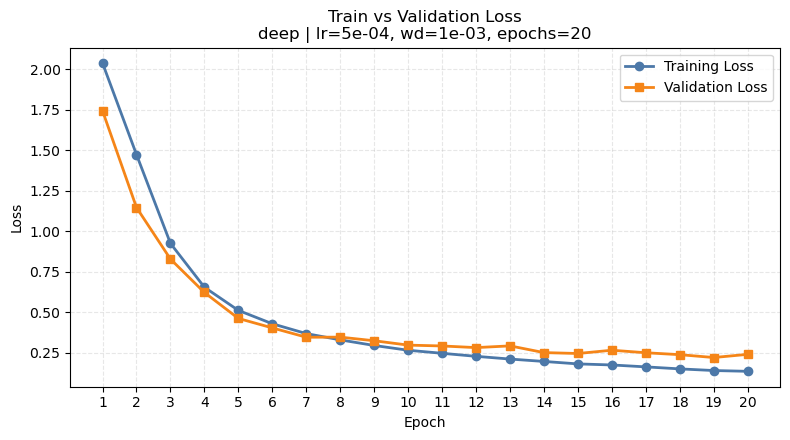

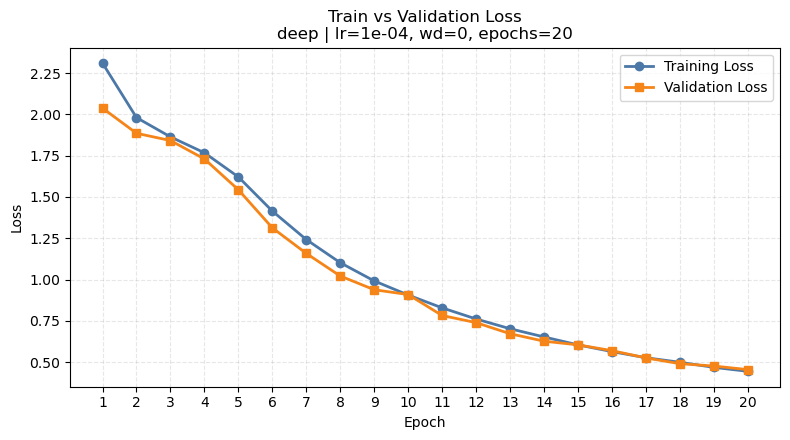

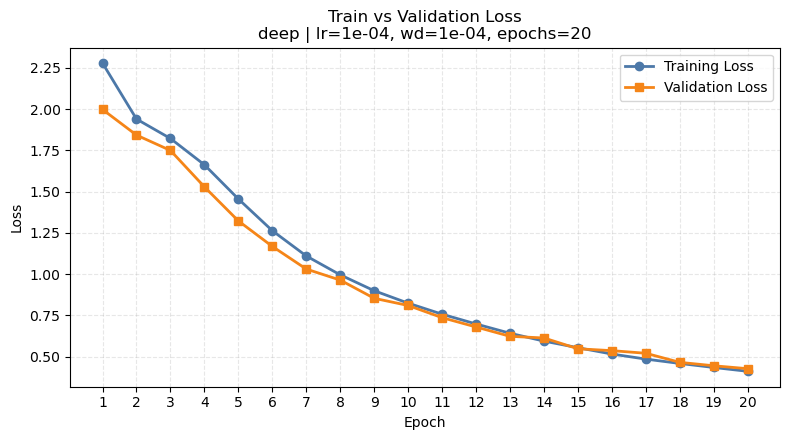

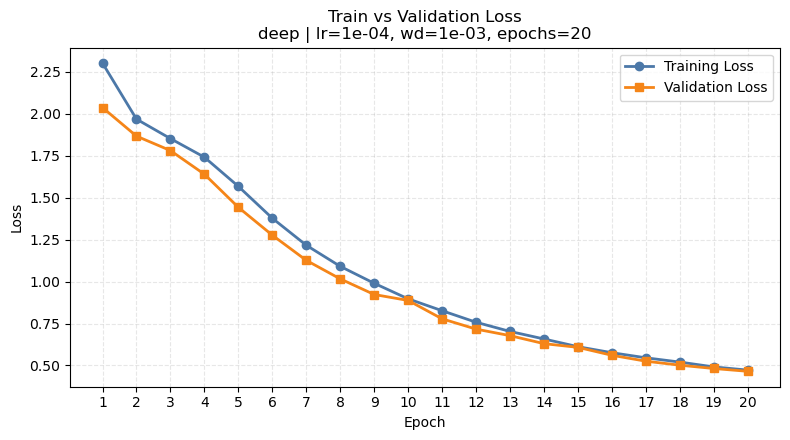

In [12]:
def compute_average_localization_loss(model, loader, preprocessor=None):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, targets in loader:
            if preprocessor is not None:
                images = preprocessor(images)

            images = images.to(device)
            targets = targets.to(device)
            preds = model(images)

            batch_size = images.size(0)
            total_loss += localization_loss(preds, targets).item() * batch_size
            total_samples += batch_size

    if total_samples == 0:
        return float('nan')
    return total_loss / total_samples


if 'training_histories' not in globals() or len(training_histories) == 0:
    raise RuntimeError('No training histories found. Run the hyperparameter tuning and training cells first.')

def format_hparam_value(value):
    if isinstance(value, float):
        if value == 0:
            return '0'
        if abs(value) < 1e-2 or abs(value) >= 1e3:
            return f'{value:.0e}'
        return f'{value:g}'
    return str(value)

def build_localization_run_metadata():
    metadata = {}

    if 'tuning_results' in globals():
        for result in tuning_results:
            if isinstance(result, dict) and result.get('trial_name') is not None:
                metadata[result['trial_name']] = result

    if not metadata and 'hyperparam_candidates' in globals():
        for trial_idx, candidate in enumerate(hyperparam_candidates, start=1):
            trial_name = (
                f"trial_{trial_idx:02d}_{candidate['model_name']}_"
                f"lr{candidate['lr']:.0e}_wd{candidate['weight_decay']:.0e}_e{candidate['num_epochs']}"
            )
            metadata[trial_name] = candidate

    return metadata

def build_localization_title(run_name, run_info):
    if not isinstance(run_info, dict):
        return run_name

    label_map = {
        'weight_decay': 'wd',
        'num_epochs': 'epochs',
    }
    model_name = str(run_info.get('model_name', run_name))
    parts = []

    for key, value in run_info.items():
        if key in {'trial_name', 'model_name', 'best_val_overall', 'train_seconds'}:
            continue
        parts.append(f"{label_map.get(key, key)}={format_hparam_value(value)}")

    if not parts:
        return model_name
    return f"{model_name} | {', '.join(parts)}"

loss_histories = {
    model_name: {
        'train_loss': list(history.get('train_loss', [])),
        'val_loss': list(history.get('val_loss', [])),
    }
    for model_name, history in training_histories.items()
}

run_metadata = build_localization_run_metadata()
ordered_model_names = list(loss_histories.keys())
print(f'Creating {len(ordered_model_names)} per-model loss graphs.')

for run_name in ordered_model_names:
    history = loss_histories[run_name]
    train_losses = history['train_loss']
    val_losses = history['val_loss']
    if len(train_losses) == 0 or len(val_losses) == 0:
        raise RuntimeError(f'Model {run_name} is missing train_loss or val_loss values.')

    epochs = list(range(1, len(train_losses) + 1))
    title = build_localization_title(run_name, run_metadata.get(run_name))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(epochs, train_losses, marker='o', linewidth=2, label='Training Loss', color='#4C78A8')
    ax.plot(epochs, val_losses, marker='s', linewidth=2, label='Validation Loss', color='#F58518')
    ax.set_title(f'Train vs Validation Loss\n{title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_xticks(epochs)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


